출처 : https://www.kaggle.com/c/bike-sharing-demand/data?select=train.csv


성능측정은 Root Mean Squared Logarithmic Error (RMSLE)

1. 누수 체크가 1순위
2. RMSLE 문제는 log 타깃 학습이 기본
3. 베이스라인으로 빠르게 방향 결정(선형 vs 트리)
4. 중요도 기반으로 FE(피처엔지니어링)를 선택(감이 아니라 근거)
5. 시간 데이터는 검증을 시간기반으로 해야 실전 성능을 보장

In [4]:
import pandas as pd

df = pd.read_csv('./data/bike_train.csv', encoding='euc-kr')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
df['holiday'].value_counts(), df['workingday'].value_counts()

(holiday
 0    10575
 1      311
 Name: count, dtype: int64,
 workingday
 1    7412
 0    3474
 Name: count, dtype: int64)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


-- 결측치 없음

# Working Day vs Holiday

In [40]:
df.groupby(['workingday', 'holiday'])[['workingday', 'holiday']].value_counts()

workingday  holiday
0           0          3163
            1           311
1           0          7412
Name: count, dtype: int64

-- Working Day 면 holiday 가 아님   
-- Working Day 가 아니면 holiday 일수도 있음   (휴일에 공휴일도 포함)
==> holiday를 삭제하는 것이 도움이 될 수도... : 미세하게 낮아짐 - 포함하는 것이 낳음

# 시간대별 카운트

In [67]:
df.groupby(['hour', 'season'])['count'].sum()

hour  season
0     1          3197
      2          6666
      3          8627
      4          6598
1     1          2120
                ...  
22    4         14411
23    1          5168
      2         11592
      3         13876
      4         10180
Name: count, Length: 96, dtype: int64

# Source Data Customization

- 일자 => 공휴일, 영업일 정보가 있어 월, 시간만 분리  2011-01-01 01:00:00 & Season 삭제
- casual, registered 삭제 : casual + registered = count : 데이터 노출(Leak)
- atemp 대신 temp - atemp 사용 : 실제온도와 체감온도의 온도차
- X, y 분리

In [5]:
df['hour'] = df['datetime'].str[11:13].astype('Int64')  # 시간 정보만 가져오기 => 숫자화
df['month'] = df['datetime'].str[5:7].astype('Int64')  # 시간 정보만 가져오기 => 숫자화
df['temp-diff'] = df['temp'] - df['atemp']
y = df['count']
X = df.drop(columns=['datetime', 'atemp', 'count', 'casual', 'registered'])
# X = df.drop(columns=['datetime', 'holiday', 'atemp', 'count', 'casual', 'registered'])
X.head(20)

,season,holiday,workingday,weather,temp,humidity,windspeed,hour,month,temp-diff
0,1,0,0,1,9.84,81,0.0000,0,1,-4.555
1,1,0,0,1,9.02,80,0.0000,1,1,-4.615
2,1,0,0,1,9.02,80,0.0000,2,1,-4.615
3,1,0,0,1,9.84,75,0.0000,3,1,-4.555
4,1,0,0,1,9.84,75,0.0000,4,1,-4.555
5,1,0,0,2,9.84,75,6.0032,5,1,-3.040
6,1,0,0,1,9.02,80,0.0000,6,1,-4.615
7,1,0,0,1,8.20,86,0.0000,7,1,-4.680
8,1,0,0,1,9.84,75,0.0000,8,1,-4.555
9,1,0,0,1,13.12,76,0.0000,9,1,-4.305


In [73]:
df.groupby(['season', 'month'])['count'].sum()

season  month
1       1         79884
        2         99113
        3        133501
2       4        167402
        5        200147
        6        220733
3       7        214617
        8        213516
        9        212529
4       10       207434
        11       176440
        12       160160
Name: count, dtype: int64

In [6]:
X = X.drop(columns=['season'])
X.head(20)

,holiday,workingday,weather,temp,humidity,windspeed,hour,month,temp-diff
0,0,0,1,9.84,81,0.0000,0,1,-4.555
1,0,0,1,9.02,80,0.0000,1,1,-4.615
2,0,0,1,9.02,80,0.0000,2,1,-4.615
3,0,0,1,9.84,75,0.0000,3,1,-4.555
4,0,0,1,9.84,75,0.0000,4,1,-4.555
5,0,0,2,9.84,75,6.0032,5,1,-3.040
6,0,0,1,9.02,80,0.0000,6,1,-4.615
7,0,0,1,8.20,86,0.0000,7,1,-4.680
8,0,0,1,9.84,75,0.0000,8,1,-4.555
9,0,0,1,13.12,76,0.0000,9,1,-4.305


In [104]:
df.groupby(['month'])['count'].sum()

month
1      79884
2      99113
3     133501
4     167402
5     200147
6     220733
7     214617
8     213516
9     212529
10    207434
11    176440
12    160160
Name: count, dtype: int64

In [105]:
df.groupby(['hour'])['count'].sum()

hour
0      25088
1      15372
2      10259
3       5091
4       2832
5       8935
6      34698
7      96968
8     165060
9     100910
10     79667
11     95857
12    116968
13    117551
14    111010
15    115960
16    144266
17    213757
18    196472
19    143767
20    104204
21     79057
22     60911
23     40816
Name: count, dtype: int64

In [6]:
y.head()

0    16
1    40
2    32
3    13
4     1
Name: count, dtype: int64

In [7]:
y.describe()

count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64

(array([4284., 2337., 1686., 1067.,  633.,  426.,  233.,  116.,   85.,
          19.]),
 array([  1. ,  98.6, 196.2, 293.8, 391.4, 489. , 586.6, 684.2, 781.8,
        879.4, 977. ]),
 <BarContainer object of 10 artists>)

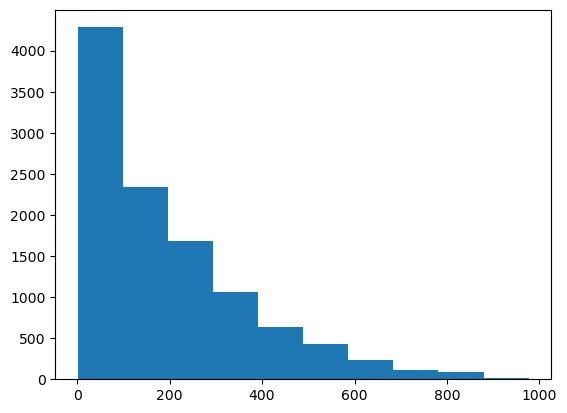

In [8]:
from matplotlib import pyplot as plt

plt.hist(y)

-- train, test 분리  
-- scaling

In [7]:
# Data 분리 및 Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Predict After Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
X_train

,holiday,workingday,weather,temp,humidity,windspeed,hour,temp-diff,month
3662,0,0,1,28.70,61,15.0013,12,-3.875,9
8648,0,1,1,33.62,52,16.9979,17,-5.015,8
7053,0,1,1,12.30,65,16.9979,6,-2.095,4
2685,0,0,1,29.52,62,8.9981,19,-4.570,6
5927,0,1,1,10.66,60,15.0013,4,-2.220,2
...,...,...,...,...,...,...,...,...,...
4859,0,1,3,22.14,60,15.0013,13,-3.620,11
3264,0,1,1,28.70,65,15.0013,22,-3.875,8
9845,0,0,1,27.06,39,27.9993,14,-4.000,10
10799,0,0,2,14.76,87,8.9981,9,-2.665,12


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_log_error
import numpy as np

def get_model_performance(real, pred) :
    
    mae = mean_absolute_error(real, pred)
    rmsle = root_mean_squared_log_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    r2 = r2_score(real, pred)
    
    print(f"Root Mean Squre Log Error : {rmsle:.3f}")
    print(f"R-Square Score : {r2:.3f}")
    print(f"Real(Test) Value Mean : {real.mean():,.1f}, Mean-Square-Root Error : {rmse:,.1f}")
    print(f"Mean Absolute Error : {mae:.3f}")

    return rmsle, mae, rmse, r2

# Lasso with y-value Log-Scaling

In [102]:
# 학습모델 선정 및 최적화
from sklearn.linear_model import Lasso
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV

# 1. 기본 모델 설정
model_lasso_base = Lasso(random_state=42, max_iter=10000)

# 2. 로그 변환을 포함한 Regressor 생성
model_lasso_tt = TransformedTargetRegressor(
    regressor=model_lasso_base,
    func=np.log1p, 
    inverse_func=np.expm1
)

# 3. 하이퍼파라미터 그리드 설정
# Lasso에서 가장 중요한 파라미터는 규제 강도를 조절하는 alpha입니다.
param_grid = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# 4. GridSearchCV 객체 생성
grid_search_lasso = GridSearchCV(
    model_lasso_tt, 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

# 5. 학습
grid_search_lasso.fit(X_train_scaled, y_train)

# 6. 결과 확인
print(f"최적 파라미터: {grid_search_lasso.best_params_}")
print(f"최고 R2 점수 (CV): {grid_search_lasso.best_score_:.4f}")

# 7. 최적의 모델 추출
best_model_lasso = grid_search_lasso.best_estimator_


# 학습에 사용된 컬럼명 리스트 (X_train이 DataFrame인 경우)
feature_names = X_train.columns

# 가중치가 0이 아닌 인덱스만 추출하여 데이터프레임 생성
used_features = pd.DataFrame({
    'feature': feature_names,
    'coef': best_model_lasso.regressor_.coef_
})

# 가중치가 0이 아닌 변수들만 필터링
selected_features = used_features[used_features['coef'] != 0]

print("Lasso가 선택한 변수 목록:")
print(selected_features.sort_values(by='coef', ascending=False))

print("Lasso가 제거한 변수 목록:")
print(used_features[used_features['coef'] == 0])

Fitting 5 folds for each of 6 candidates, totalling 30 fits
최적 파라미터: {'regressor__alpha': 0.01}
최고 R2 점수 (CV): 0.1731
Lasso가 선택한 변수 목록:
      feature      coef
6        hour  0.664084
3        temp  0.337285
8       month  0.207811
5   windspeed  0.015857
1  workingday -0.023119
7   temp-diff -0.035850
4    humidity -0.295535
Lasso가 제거한 변수 목록:
   feature  coef
0  holiday  -0.0
2  weather  -0.0


In [103]:
# y_pred = model_linear.predict(X_test)
y_pred = best_model_lasso.predict(X_test_scaled)

r2, rmse = get_model_performance(y_test, y_pred)

R-Square Score : 0.152
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 167.8
Mean Absolute Error : 112.513


# Ridge Model : 2차 다항식(Polynomial Features) + Log Scaling of y

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge, RidgeCV

# 1. X 데이터 처리를 위한 파이프라인 (스케일링 없이 2차항만 적용, 이전 단계에서 적용)
# include_bias=False는 상수항(1)을 추가하지 않겠다는 설정입니다 (Ridge에서 자동으로 처리 가능)
x_poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge_cv', RidgeCV(alphas=np.logspace(-3, 3, 10), cv=5))
])

# 2. y값 로그 변환을 포함한 통합 모델 설정
# func=np.log1p: 학습 시 y에 로그를 취함
# inverse_func=np.expm1: 예측 시 원래 단위로 복원함
model_poly_ridge = TransformedTargetRegressor(
    regressor=x_poly_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# 3. 모델 학습
# X_train은 변환 전 원본, y_train도 변환 전 원본을 그대로 넣습니다.
model_poly_ridge.fit(X_train_scaled, y_train)

best_alpha = model_poly_ridge.regressor_.named_steps['ridge_cv'].alpha_
print(f"최적의 Alpha: {best_alpha}")

최적의 Alpha: 46.41588833612773


In [81]:
# 1. 2차항 변환기(PolynomialFeatures)와 학습된 Ridge 모델 추출
poly_transformer = model_poly_ridge.regressor_.named_steps['poly']
ridge_model = model_poly_ridge.regressor_.named_steps['ridge_cv']

# 2. 확장된 피처 이름 생성 
# (원본 feature_names 리스트가 필요합니다. 예: ['temp', 'humid'])
poly_feature_names = poly_transformer.get_feature_names_out(feature_names)

# 3. 계수(Coefficients) 추출
# RidgeCV는 선형 모델이므로 coef_를 통해 기여도를 확인합니다.
weights = ridge_model.coef_

# 4. 데이터프레임 생성 및 정렬
feature_contribution = pd.DataFrame({
    'Feature': poly_feature_names,
    'Weight': weights
})

# 5. 영향력(절댓값) 기준 내림차순 정렬
feature_contribution['Abs_Weight'] = feature_contribution['Weight'].abs()
feature_contribution = feature_contribution.sort_values(by='Abs_Weight', ascending=False)

print("--- 2차항 확장 피처별 기여도 (Top 10) ---")
print(feature_contribution[['Feature', 'Weight']].head(10))

--- 2차항 확장 피처별 기여도 (Top 10) ---
                Feature    Weight
6                  hour  0.707553
48               hour^2 -0.574466
3                  temp  0.344455
4              humidity -0.195469
33               temp^2 -0.147420
23      workingday hour  0.138502
8                 month  0.125046
39           humidity^2 -0.095910
21  workingday humidity  0.084941
20      workingday temp -0.077832


In [26]:
np.logspace(-3, 3, 10)

array([1.00000000e-03, 4.64158883e-03, 2.15443469e-02, 1.00000000e-01,
       4.64158883e-01, 2.15443469e+00, 1.00000000e+01, 4.64158883e+01,
       2.15443469e+02, 1.00000000e+03])

In [38]:
# 4. 결과 확인
y_pred = model_poly_ridge.predict(X_test_scaled)

r2, rmse = get_model_performance(y_test, y_pred)

NameError: name 'model_poly_ridge' is not defined

# Random Forrest Model with y-value log-scaling

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor # 타겟 변환용

# 1. 기본 모델 설정
model_rfr_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# 2. 로그 변환을 포함한 Regressor 생성
# func=np.log1p는 학습 시 로그를 취하고, inverse_func=np.expm1은 예측 시 복원합니다.
model_rfr_tt = TransformedTargetRegressor(regressor=model_rfr_base, 
                                      func=np.log1p, 
                                      inverse_func=np.expm1)

# 학습용 문제와 정답을 주고 모델 학습시키기
# 3. 하이퍼파라미터 그리드 수정
# TransformedTargetRegressor를 사용할 때는 파라미터 이름 앞에 'regressor__'를 붙여야 합니다.
param_grid = {
    'regressor__n_estimators': [100, 200, 300],         # 트리 개수 (많을수록 안정적이나 300 이상은 효율 저하 가능)
    'regressor__max_depth': [None, 10, 20, 30],         # 트리 최대 깊이 (None은 끝까지 분할, 10~20은 과적합 방지용)
    'regressor__min_samples_split': [2, 5, 10],         # 노드 분할을 위한 최소 샘플 수 (데이터 1% 내외인 10까지 권장)
    'regressor__min_samples_leaf': [1, 2, 4],           # 리프 노드가 되기 위한 최소 샘플 수
    'regressor__max_features': ['sqrt', 'log2', None]   # 각 노드 분할 시 고려할 특성 수 (None은 전체 특성 사용)
}

# 3. GridSearchCV 객체 생성 (5-fold 교차 검증 사용)
grid_search = GridSearchCV(model_rfr_tt, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)

# 4. 학습 (X_train, y_train은 앞서 변환한 NumPy 배열)
grid_search.fit(X_train_scaled, y_train)

# 5. 최적의 결과 확인
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최고 정확도: {grid_search.best_score_:.4f}")

# 6. 최적의 모델 추출
model_rfr_opt = grid_search.best_estimator_

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
최적 파라미터: {'regressor__max_depth': 30, 'regressor__max_features': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
최고 정확도: -44.8684


In [29]:
# 3. 하이퍼파라미터 그리드 수정
# TransformedTargetRegressor를 사용할 때는 파라미터 이름 앞에 'regressor__'를 붙여야 합니다.
param_grid = {
    'regressor__n_estimators': [230, 270, 300],         # 트리 개수 (많을수록 안정적이나 300 이상은 효율 저하 가능)
    'regressor__max_depth': [23, 27, 30],         # 트리 최대 깊이 (None은 끝까지 분할, 10~20은 과적합 방지용)
    'regressor__min_samples_split': [2, 5],         # 노드 분할을 위한 최소 샘플 수 (데이터 1% 내외인 10까지 권장)
    'regressor__min_samples_leaf': [1, 2],           # 리프 노드가 되기 위한 최소 샘플 수
    'regressor__max_features': [None]              # 각 노드 분할 시 고려할 특성 수 (None은 전체 특성 사용)
}

# 3. GridSearchCV 객체 생성 (5-fold 교차 검증 사용)
grid_search = GridSearchCV(model_rfr_tt, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)

# 4. 학습 (X_train, y_train은 앞서 변환한 NumPy 배열)
grid_search.fit(X_train_scaled, y_train)

# 5. 최적의 결과 확인
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최고 정확도: {grid_search.best_score_:.4f}")

# 6. 최적의 모델 추출
model_rfr_opt = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
최적 파라미터: {'regressor__max_depth': 30, 'regressor__max_features': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
최고 정확도: -44.8684


In [30]:
# 1. 최적의 모델(model_rfr_opt) 내부에서 실제 RandomForest 객체에 접근
# TransformedTargetRegressor를 사용했으므로 .regressor_를 통해 접근합니다.
# 2. 특성 중요도 가져오기
importances = model_rfr_opt.regressor_.feature_importances_

# 3. 특성 이름과 매칭 (feature_names 변수가 필요함)
# feature_names가 없다면: feature_names = [f'Features_{i}' for i in range(X_train_scaled.shape[1])]
rf_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 4. 중요도 순으로 내림차순 정렬
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 5. 결과 출력
print("Top 핵심 요소:")
print(rf_importance_df)

Top 핵심 요소:
      Feature  Importance
6        hour    0.760896
3        temp    0.063351
1  workingday    0.051881
7       month    0.046138
4    humidity    0.033157
5   windspeed    0.015557
8   temp-diff    0.014957
2     weather    0.011756
0     holiday    0.002306


In [31]:
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# 학습 후 예측 및 평가
# ==========================================
# 학습에 사용하지 않은 테스트용 문제(X_test)를 주고 예측해보기
model_rfr_opt.fit(X_train_scaled, y_train)
y_pred = model_rfr_opt.predict(X_test_scaled)

# 실제 정답(y_test)과 모델이 예측한 값(y_pred)을 비교하여 정확도 계산
get_model_performance(y_test, y_pred)

Root Mean Squre Log Error : 0.412
R-Square Score : 0.843
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 72.2
Mean Absolute Error : 45.795


(0.41244778029732976,
 45.79508045631574,
 np.float64(72.17010873178094),
 0.8432387664145815)

# XGBRegressor

In [33]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor # 타겟 변환용


# 1. 기본 모델 설정
model_xgb_base = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

# 2. 로그 변환을 포함한 Regressor 생성
# func=np.log1p는 학습 시 로그를 취하고, inverse_func=np.expm1은 예측 시 복원합니다.
model_xgb_tt = TransformedTargetRegressor(regressor=model_xgb_base, 
                                      func=np.log1p, 
                                      inverse_func=np.expm1)

# 학습용 문제와 정답을 주고 모델 학습시키기
# 3. 하이퍼파라미터 그리드 설정
# XGBoost의 핵심 파라미터들로 구성
param_grid_org = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.05, 0.1, 0.2], # 학습률
    'regressor__max_depth': [3, 5, 7],             # 트리 깊이 (너무 깊으면 과적합 위험)
    'regressor__subsample': [0.7, 0.8, 0.9],       # 각 트리 학습 시 샘플링 비율
    'regressor__colsample_bytree': [0.7, 0.8, 0.9] # 각 트리 학습 시 피처 사용 비율
}

param_grid = {
    'regressor__n_estimators': [250, 270, 300],
    'regressor__learning_rate': [0.01, 0.05, 0.1], # 학습률
    'regressor__max_depth': [6, 7],             # 트리 깊이 (너무 깊으면 과적합 위험)
    'regressor__subsample': [0.8, 0.9],       # 각 트리 학습 시 샘플링 비율
    'regressor__colsample_bytree': [0.8, 0.9] # 각 트리 학습 시 피처 사용 비율
}

# 3. GridSearchCV 객체 생성 (5-fold 교차 검증 사용)
grid_search_xgb = GridSearchCV(model_xgb_tt, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)

# 4. 학습 (X_train, y_train은 앞서 변환한 NumPy 배열)
grid_search_xgb.fit(X_train_scaled, y_train)

# 5. 최적의 결과 확인
print(f"최적 파라미터: {grid_search_xgb.best_params_}")
print(f"최고 정확도: {grid_search_xgb.best_score_:.4f}")

# 6. 최적의 모델 추출
model_xgb_opt = grid_search_xgb.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
최적 파라미터: {'regressor__colsample_bytree': 0.9, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__n_estimators': 300, 'regressor__subsample': 0.9}
최고 정확도: -41.1699


In [34]:
# 1. 최적의 모델(model_rfr_opt) 내부에서 실제 RandomForest 객체에 접근
# TransformedTargetRegressor를 사용했으므로 .regressor_를 통해 접근합니다.
# 2. 특성 중요도 가져오기
importances = model_xgb_opt.regressor_.feature_importances_

# 3. 특성 이름과 매칭 (feature_names 변수가 필요함)
# feature_names가 없다면: feature_names = [f'Features_{i}' for i in range(X_train_scaled.shape[1])]
rf_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 4. 중요도 순으로 내림차순 정렬
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 5. 결과 출력
print("Top 10 핵심 요소:")
print(rf_importance_df)

Top 10 핵심 요소:
      Feature  Importance
6        hour    0.554993
1  workingday    0.182568
3        temp    0.070168
7       month    0.058037
4    humidity    0.042762
2     weather    0.038924
0     holiday    0.026091
8   temp-diff    0.014211
5   windspeed    0.012246


In [36]:
# ==========================================
# 학습 후 예측 및 평가
# ==========================================
# 학습에 사용하지 않은 테스트용 문제(X_test)를 주고 예측해보기
model_xgb_opt.fit(X_train_scaled, y_train)
y_pred = model_xgb_opt.predict(X_test_scaled)

# 실제 정답(y_test)과 모델이 예측한 값(y_pred)을 비교하여 정확도 계산
get_model_performance(y_test, y_pred)

Root Mean Squre Log Error : 0.379
R-Square Score : 0.872
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 65.2
Mean Absolute Error : 41.790


(0.3793577551841736,
 41.790374755859375,
 np.float64(65.24423391069705),
 0.8718825578689575)

# Decision Tree with Log-Scaling

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor

# 1. 기본 모델 설정
model_dt_base = DecisionTreeRegressor(random_state=42)

# 2. 로그 변환을 포함한 Regressor 생성
model_dt_tt = TransformedTargetRegressor(
    regressor=model_dt_base,
    func=np.log1p, 
    inverse_func=np.expm1
)

# 3. 하이퍼파라미터 그리드 설정
param_grid = {
    'regressor__max_depth': [None, 5, 10, 20],       # 트리의 최대 깊이
    'regressor__min_samples_split': [2, 5, 10],    # 노드 분할을 위한 최소 샘플 수
    'regressor__min_samples_leaf': [1, 2, 4],       # 리프 노드의 최소 샘플 수
    'regressor__max_features': [None, 'sqrt', 'log2'] # 분할 시 고려할 특성 수
}

# 4. GridSearchCV 객체 생성
grid_search_dt = GridSearchCV(
    model_dt_tt, 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

# 5. 학습 (X_train_scaled와 y_train 사용)
grid_search_dt.fit(X_train_scaled, y_train)

# 6. 최적의 모델 추출
best_model_dt = grid_search_dt.best_estimator_

# 7. 특성 중요도(Feature Importance) 확인
# 결정 트리는 coef_ 대신 feature_importances_를 사용합니다.
importances = best_model_dt.regressor_.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns, # 미리 정의된 컬럼명 리스트
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(f"최적 파라미터: {grid_search_dt.best_params_}")
print(f"최고 R2 점수: {grid_search_dt.best_score_:.4f}")
print("\n[특성 중요도")
print(feature_importance_df)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적 파라미터: {'regressor__max_depth': 10, 'regressor__max_features': None, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 2}
최고 R2 점수: 0.7856

[특성 중요도
      Feature  Importance
6        hour    0.810939
3        temp    0.059438
1  workingday    0.052816
8       month    0.037773
4    humidity    0.020315
2     weather    0.009001
5   windspeed    0.004283
7   temp-diff    0.003973
0     holiday    0.001462


In [96]:
# ==========================================
# 학습 후 예측 및 평가
# ==========================================
# 학습에 사용하지 않은 테스트용 문제(X_test)를 주고 예측해보기
# best_model_dt.fit(X_train_scaled, y_train)
y_pred = best_model_dt.predict(X_test_scaled)

# 실제 정답(y_test)과 모델이 예측한 값(y_pred)을 비교하여 정확도 계산
r2, rmse = get_model_performance(y_test, y_pred)

R-Square Score : 0.773
Real(Test) Value Mean : 194.4, Mean-Square-Root Error : 86.9
Mean Absolute Error : 55.447


In [ ]:
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.pipeline import Pipeline

def train_and_evaluate_optimized(model, name, preprocess_used, param_grid=None):
    """
    - model: sklearn 호환 regressor
    - name: 모델 이름 (출력용)
    - preprocess_used: 전처리기 객체
    - param_grid: GridSearchCV용 파라미터 딕셔너리 (키 앞에 'model__' 필수)
    """
    
    # 1. 파이프라인 구성
    pipe = Pipeline([
        ("prep", preprocess_used),
        ("model", model)
    ])

    # 2. 하이퍼파라미터 튜닝 (param_grid가 있을 경우)
    if param_grid:
        print(f"[{name}] 하이퍼파라미터 최적화 시작...")
        # 타겟을 이미 로그변환하여 fit하므로 scoring은 MSE(로그상태의 에러) 기준
        grid_search = GridSearchCV(
            pipe, 
            param_grid, 
            cv=5, 
            scoring='neg_mean_squared_error', 
            n_jobs=-1, 
            verbose=1
        )
        grid_search.fit(X_train, np.log1p(y_train))
        
        best_model = grid_search.best_estimator_
        print(f"최적 파라미터: {grid_search.best_params_}")
    else:
        # 파라미터 그리드가 없으면 기본 설정으로 학습
        best_model = pipe.fit(X_train, np.log1p(y_train))

    # 3. 예측 및 역변환
    # 타겟이 로그변환(log1p)된 상태이므로 expm1로 복원
    pred_log = best_model.predict(X_valid)
    pred = np.expm1(pred_log)
    pred = np.maximum(0, pred) # 음수 방지

    print(f"\n[{name} Evaluation]")
    evaluate_regr(y_valid, pred)
    
    return best_model

# --- 사용 예시 ---
# rfr_params = {
#     'model__n_estimators': [100, 200],
#     'model__max_depth': [None, 10, 20],
#     'model__max_features': ['sqrt', None]
# }
# best_rfr = train_and_evaluate_optimized(RandomForestRegressor(random_state=42), "RF_Opt", preprocess, rfr_params)
